### West Virginia

BYM and BYM-TDA 

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt


from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve
import geopandas as gpd

# these libraries are not dependencies of pymc
import networkx as nx
import nutpie
import libpysal as ps

In [2]:
RANDOM_SEED = 8926
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

In [3]:
current_path = os.getcwd()

In [4]:
state_abb = "WV"
state_abb_lower = state_abb.lower()

Load the data

In [5]:
# SVI
svi_tda_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"tda_summaries_2018_{state_abb}_down.csv"), dtype={'STCNTY': str})

# SMR
smr_data = pd.read_csv(os.path.join(current_path, "data", "processed_data", f"smr_data_2018_{state_abb}.csv"), dtype={'FIPS': str})

# GEO: get geometry data
geo_data = gpd.read_file(os.path.join(current_path, "data", "raw_data", "SVI2018_US_county.gdb"), dtype={"FIPS": str})

geo_data = geo_data[['FIPS', 'geometry','ST_ABBR']]

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DTYPE
  return ogr_read(


In [6]:
# combine smr on FIPS and svi data on STCNTY - left
combined_data = pd.merge(smr_data, svi_tda_data, left_on="FIPS", right_on="STCNTY", how="left")

# merge combined data with geo data
combined_data = pd.merge(combined_data, geo_data, on="FIPS", how="left")

In [7]:
# print the shape
print(f"Shape of the combined data: {combined_data.shape}")

Shape of the combined data: (55, 89)


In [8]:
# get the 'state' data

combined_data = combined_data[combined_data['ST_ABBR'] == state_abb]

In [9]:
combined_data.shape

(55, 89)

In [10]:
# Adding this just to plot original data!
# Replace 0 with NaN in observed_deaths column
combined_data_map = combined_data.copy()
combined_data_map["observed_deaths"] = combined_data_map["observed_deaths"].replace(0.0, np.nan)

gdf_map = gpd.GeoDataFrame(combined_data_map, geometry='geometry')

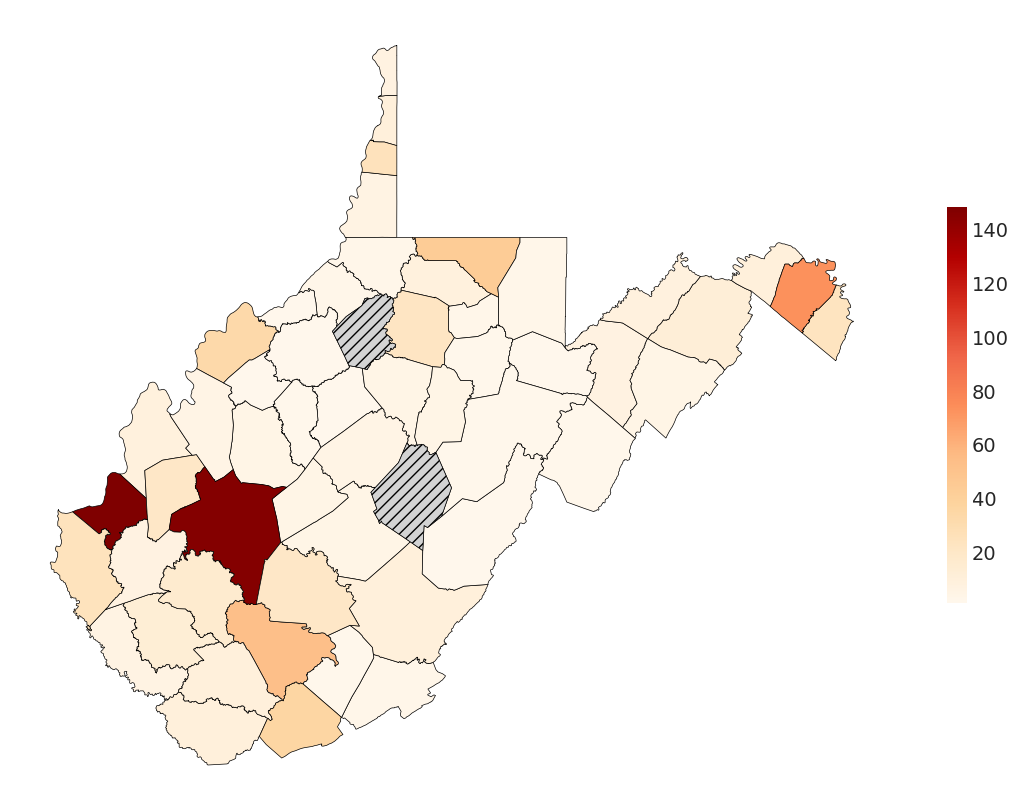

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd

# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf_map.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"observed_deaths.png"), bbox_inches='tight', dpi=300)

Cleaning the data: Removing the rows with missing observed deaths, islands, few states

In [12]:
# filter by column to have columns start with EP_ or SMR and geometry and FIPS and observed_death and expected_death
combined_data = combined_data.filter(regex='EP_|SMR|geometry|FIPS|observed_death|expected_death')

# drop the rows with observed_death = 0
combined_data = combined_data[combined_data['observed_deaths'] > 0]

# make it a geodataframe
gdf = gpd.GeoDataFrame(combined_data, geometry='geometry')

# Compute Queen adjacency
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# if we keep the islands it will cause error in the adjacency computation(empty adjacencies)
# Get the islands fips to a list
islands = w.islands

# drop the islands
combined_data = combined_data[~combined_data["FIPS"].isin(islands)]

# drop rows with FIPS starts with 72, 78, 02, 15, 60
combined_data = combined_data[~combined_data['FIPS'].str.startswith(('72', '78', '02', '15', '60'))]

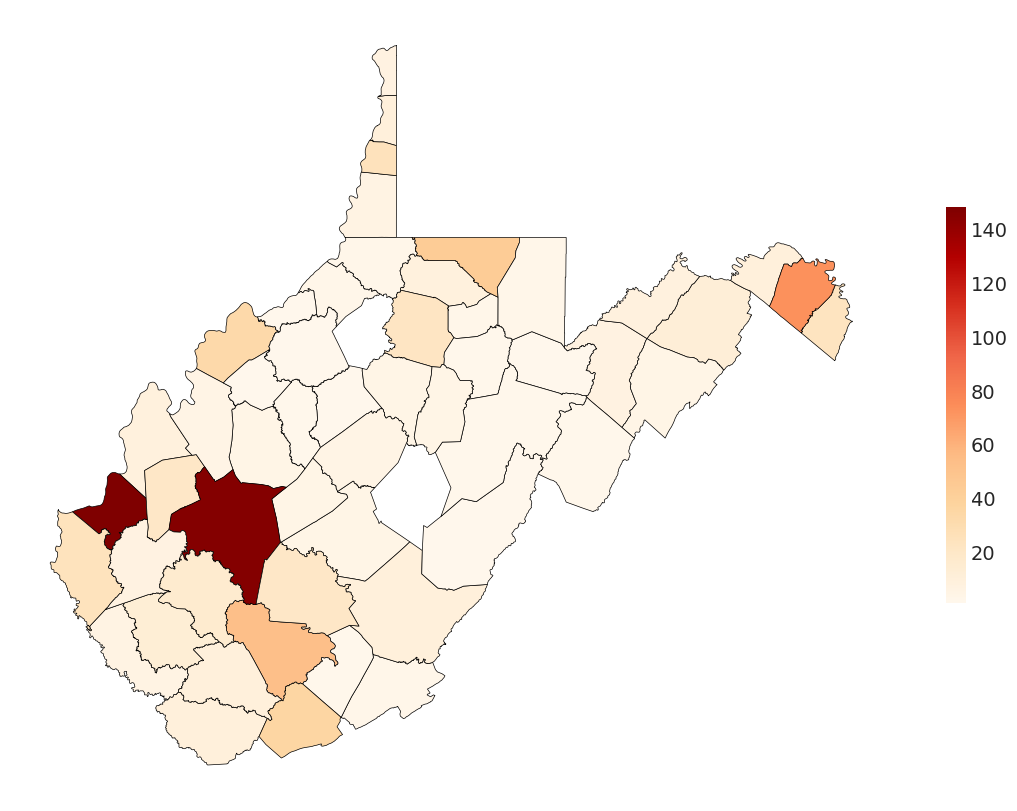

In [13]:
# plot a map with observed death counts
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

gdf.plot(
    column="observed_deaths", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.show()

Combine TDA summaries for each state(all variables)

In [14]:
# get the column names with _AL
al_cols = combined_data.filter(regex='_AL').columns

print(f"Columns with _AL: {al_cols}")

# sum the columns with _AL
combined_data['AL'] = combined_data[al_cols].sum(axis=1)

# drop the columns with _AL
# combined_data.drop(columns=al_cols, inplace=True)

# get the column names with _TL

tl_cols = combined_data.filter(regex='_TL').columns

print(f"Columns with _TL: {tl_cols}")

# sum the columns with _TL
combined_data['TL'] = combined_data[tl_cols].sum(axis=1)

# drop the columns with _TL
# combined_data.drop(columns=tl_cols, inplace=True)

# get the column names with _AML
aml_cols = combined_data.filter(regex='_AML').columns

print(f"Columns with _AML: {aml_cols}")

# sum the columns with _AML
combined_data['AML'] = combined_data[aml_cols].sum(axis=1)

# drop the columns with _AML
# combined_data.drop(columns=aml_cols, inplace=True)

# get the column names with _TML
tml_cols = combined_data.filter(regex='_TML').columns

print(f"Columns with _TML: {tml_cols}")

# sum the columns with _TML
combined_data['TML'] = combined_data[tml_cols].sum(axis=1)

# drop the columns with _TML
# combined_data.drop(columns=tml_cols, inplace=True)

Columns with _AL: Index(['EP_POV_AL', 'EP_UNEMP_AL', 'EP_PCI_AL', 'EP_NOHSDP_AL',
       'EP_UNINSUR_AL', 'EP_AGE65_AL', 'EP_AGE17_AL', 'EP_DISABL_AL',
       'EP_SNGPNT_AL', 'EP_LIMENG_AL', 'EP_MINRTY_AL', 'EP_MUNIT_AL',
       'EP_MOBILE_AL', 'EP_CROWD_AL', 'EP_NOVEH_AL', 'EP_GROUPQ_AL'],
      dtype='object')
Columns with _TL: Index(['EP_POV_TL', 'EP_UNEMP_TL', 'EP_PCI_TL', 'EP_NOHSDP_TL',
       'EP_UNINSUR_TL', 'EP_AGE65_TL', 'EP_AGE17_TL', 'EP_DISABL_TL',
       'EP_SNGPNT_TL', 'EP_LIMENG_TL', 'EP_MINRTY_TL', 'EP_MUNIT_TL',
       'EP_MOBILE_TL', 'EP_CROWD_TL', 'EP_NOVEH_TL', 'EP_GROUPQ_TL'],
      dtype='object')
Columns with _AML: Index(['EP_POV_AML', 'EP_UNEMP_AML', 'EP_PCI_AML', 'EP_NOHSDP_AML',
       'EP_UNINSUR_AML', 'EP_AGE65_AML', 'EP_AGE17_AML', 'EP_DISABL_AML',
       'EP_SNGPNT_AML', 'EP_LIMENG_AML', 'EP_MINRTY_AML', 'EP_MUNIT_AML',
       'EP_MOBILE_AML', 'EP_CROWD_AML', 'EP_NOVEH_AML', 'EP_GROUPQ_AML'],
      dtype='object')
Columns with _TML: Index(['EP_POV_TML', '

Get the adjacency matrix

In [15]:
# create the queen adjacency matrix
w = ps.weights.Queen.from_dataframe(combined_data, ids=combined_data["FIPS"])

# Spatial adjacency matrix (N x N) with binary entries for neighbor relationships.
# make it into a matrix
W = w.full()[0]

In [16]:
# print the shape of W
print(f"Shape of W: {W.shape}")

Shape of W: (53, 53)


Prepare data and adjacency structures

In [17]:
y = combined_data["observed_deaths"].values
E = combined_data["expected_deaths"].values

EP_POV_AV_ORI = combined_data["EP_POV_AV_ORI"].values
EP_UNEMP_AV_ORI = combined_data["EP_UNEMP_AV_ORI"].values
EP_PCI_AV_ORI = combined_data["EP_PCI_AV_ORI"].values
EP_NOHSDP_AV_ORI = combined_data["EP_NOHSDP_AV_ORI"].values
EP_AGE65_AV_ORI = combined_data["EP_AGE65_AV_ORI"].values
EP_AGE17_AV_ORI = combined_data["EP_AGE17_AV_ORI"].values
EP_DISABL_AV_ORI = combined_data["EP_DISABL_AV_ORI"].values
EP_SNGPNT_AV_ORI = combined_data["EP_SNGPNT_AV_ORI"].values
EP_MINRTY_AV_ORI = combined_data["EP_MINRTY_AV_ORI"].values
EP_LIMENG_AV_ORI = combined_data["EP_LIMENG_AV_ORI"].values
EP_MUNIT_AV_ORI = combined_data["EP_MUNIT_AV_ORI"].values
EP_MOBILE_AV_ORI = combined_data["EP_MOBILE_AV_ORI"].values
EP_CROWD_AV_ORI = combined_data["EP_CROWD_AV_ORI"].values
EP_NOVEH_AV_ORI = combined_data["EP_NOVEH_AV_ORI"].values
EP_GROUPQ_AV_ORI = combined_data["EP_GROUPQ_AV_ORI"].values

EP_POV_AL = combined_data["EP_POV_AL"].values
EP_UNEMP_AL = combined_data["EP_UNEMP_AL"].values
EP_PCI_AL = combined_data["EP_PCI_AL"].values
EP_NOHSDP_AL = combined_data["EP_NOHSDP_AL"].values
EP_AGE65_AL = combined_data["EP_AGE65_AL"].values
EP_AGE17_AL = combined_data["EP_AGE17_AL"].values
EP_DISABL_AL = combined_data["EP_DISABL_AL"].values
EP_SNGPNT_AL = combined_data["EP_SNGPNT_AL"].values 
EP_MINRTY_AL = combined_data["EP_MINRTY_AL"].values
EP_LIMENG_AL = combined_data["EP_LIMENG_AL"].values
EP_MUNIT_AL = combined_data["EP_MUNIT_AL"].values
EP_MOBILE_AL = combined_data["EP_MOBILE_AL"].values
EP_CROWD_AL = combined_data["EP_CROWD_AL"].values
EP_NOVEH_AL = combined_data["EP_NOVEH_AL"].values
EP_GROUPQ_AL = combined_data["EP_GROUPQ_AL"].values

# Mean standerdizing "AL", "TL", "AML", "TML"
for col in ['AL', 'TL', 'AML', 'TML']:
    mean_value = combined_data[col].mean()
    std_value = combined_data[col].std()
    combined_data[col] = (combined_data[col] - mean_value) / std_value

AL = combined_data["AL"].values
TL = combined_data["TL"].values
AML = combined_data["AML"].values
TML = combined_data["TML"].values

E[E < 10] = 10
log_E = np.log(E)

area_idx = combined_data["FIPS"].values
coords = {"area_idx": area_idx}

N = len(y)

# # THETA = df_clean["AL"].values
# theta_values = combined_data.set_index("FIPS")["AL"].to_dict()
# theta = np.array([theta_values[fips] for fips in area_idx])

Scaling Factors

In [18]:
def scaling_factor_sp(A):
    """Compute the scaling factor from an adjacency matrix.
    This function uses sparse matrix computations and is most
    efficient on sparse adjacency matrices. Used in the BYM2 model.
    The scaling factor is a measure of the variance in the number of
    edges across nodes in a connected graph.
    Only works for fully connected graphs. The argument for scaling
    factors is developed by Andrea Riebler, Sigrunn H. Sørbye,
    Daniel Simpson, Havard Rue in "An intuitive Bayesian spatial
    model for disease mapping that accounts for scaling"
    https://arxiv.org/abs/1601.01180"""

    # Computes the precision matrix in sparse format
    # from an adjacency matrix.

    num_neighbors = A.sum(axis=1)
    A = sparse.csc_matrix(A)
    D = sparse.diags(num_neighbors, format="csc")
    Q = D - A

    # add a small jitter along the diagonal

    Q_perturbed = Q + sparse.diags(np.ones(Q.shape[0])) * max(Q.diagonal()) * np.sqrt(
        np.finfo(np.float64).eps
    )

    # Compute a version of the pseudo-inverse

    n = Q_perturbed.shape[0]
    b = sparse.identity(n, format="csc")
    Sigma = spsolve(Q_perturbed, b)
    A = np.ones(n)
    W = Sigma @ A.T
    Q_inv = Sigma - np.outer(W * solve(A @ W, np.ones(1)), W.T)

    # Compute the geometric mean of the diagonal on a
    # precision matrix.

    return np.exp(np.sum(np.log(np.diag(Q_inv))) / n)


scaling_factor = scaling_factor_sp(W)
scaling_factor

0.5991931651817699

In [19]:
import pymc as pm
import arviz as az

In [25]:
coefficients = [
    "beta_pov", "beta_unemp", "beta_pci", "beta_nohsdp", 
    "beta_age65", "beta_age17", "beta_disabl", "beta_sngpnt", 
    "beta_minrty", "beta_limeng", "beta_munit", "beta_mobile", 
    "beta_crowd", "beta_noveh", "beta_groupq"
]

####  I. BYM-T model 1: Uniform case

In [26]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_1:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)
   beta_unemp = pm.Normal("beta_unemp", mu=0, sigma=1)
   beta_pci = pm.Normal("beta_pci", mu=0, sigma=1)
   beta_nohsdp = pm.Normal("beta_nohsdp", mu=0, sigma=1)
   beta_age65 = pm.Normal("beta_age65", mu=0, sigma=1)
   beta_age17 = pm.Normal("beta_age17", mu=0, sigma=1)
   beta_disabl = pm.Normal("beta_disabl", mu=0, sigma=1)
   beta_sngpnt = pm.Normal("beta_sngpnt", mu=0, sigma=1)
   beta_minrty = pm.Normal("beta_minrty", mu=0, sigma=1)
   beta_limeng = pm.Normal("beta_limeng", mu=0, sigma=1)
   beta_munit = pm.Normal("beta_munit", mu=0, sigma=1)
   beta_mobile = pm.Normal("beta_mobile", mu=0, sigma=1)
   beta_crowd = pm.Normal("beta_crowd", mu=0, sigma=1)
   beta_noveh = pm.Normal("beta_noveh", mu=0, sigma=1)
   beta_groupq = pm.Normal("beta_groupq", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   alpha = pm.Dirichlet("alpha", a=np.array([1.0, 1.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                  beta_unemp * EP_UNEMP_AV_ORI +
                  beta_pci * EP_PCI_AV_ORI +
                  beta_nohsdp * EP_NOHSDP_AV_ORI +
                  beta_age65 * EP_AGE65_AV_ORI +
                  beta_age17 * EP_AGE17_AV_ORI +
                  beta_disabl * EP_DISABL_AV_ORI +
                  beta_sngpnt * EP_SNGPNT_AV_ORI +
                  beta_minrty * EP_MINRTY_AV_ORI +
                  beta_limeng * EP_LIMENG_AV_ORI +
                  beta_munit * EP_MUNIT_AV_ORI +
                  beta_mobile * EP_MOBILE_AV_ORI +
                  beta_crowd * EP_CROWD_AV_ORI +
                  beta_noveh * EP_NOVEH_AV_ORI +
                  beta_groupq * EP_GROUPQ_AV_ORI +
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

Sampling the data

In [27]:
with model_1:

    # # Sample from the model:
    trace_model_1 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, beta_unemp, beta_pci, beta_nohsdp, beta_age65, beta_age17, beta_disabl, beta_sngpnt, beta_minrty, beta_limeng, beta_munit, beta_mobile, beta_crowd, beta_noveh, beta_groupq, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 357 seconds.


R hat statistics

In [28]:
# Calculate r_hat for sigma and alpha
rhat_data_model_1 = az.rhat(trace_model_1, var_names=["sigma","alpha","beta_pov","beta_unemp","beta_pci","beta_nohsdp","beta_age65","beta_age17","beta_disabl","beta_sngpnt","beta_minrty","beta_limeng","beta_munit","beta_mobile","beta_crowd","beta_noveh","beta_groupq"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_1["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_1["alpha"].values}')

R-hat for sigma: 0.9999742035844132
R-hat for alpha: [1.00008162 0.99994815 1.00003564]


In [29]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_1[var].values}')

R-hat for beta_pov: 0.9999895414796627
R-hat for beta_unemp: 1.0001679558376468
R-hat for beta_pci: 1.0000143127349708
R-hat for beta_nohsdp: 1.0000504690909202
R-hat for beta_age65: 1.0004552206360917
R-hat for beta_age17: 1.0000884498811295
R-hat for beta_disabl: 1.0004344461993653
R-hat for beta_sngpnt: 1.0000922206130152
R-hat for beta_minrty: 1.0000182816303973
R-hat for beta_limeng: 1.000156261376984
R-hat for beta_munit: 1.0000807754945578
R-hat for beta_mobile: 1.0001411778294265
R-hat for beta_crowd: 1.0002106357915765
R-hat for beta_noveh: 1.0002110252606355
R-hat for beta_groupq: 1.0000160678212107


Rank plots

array([<Axes: title={'center': 'alpha\n0'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n1'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'alpha\n2'}, xlabel='Rank (all chains)', ylabel='Chain'>,
       <Axes: title={'center': 'sigma'}, xlabel='Rank (all chains)', ylabel='Chain'>],
      dtype=object)

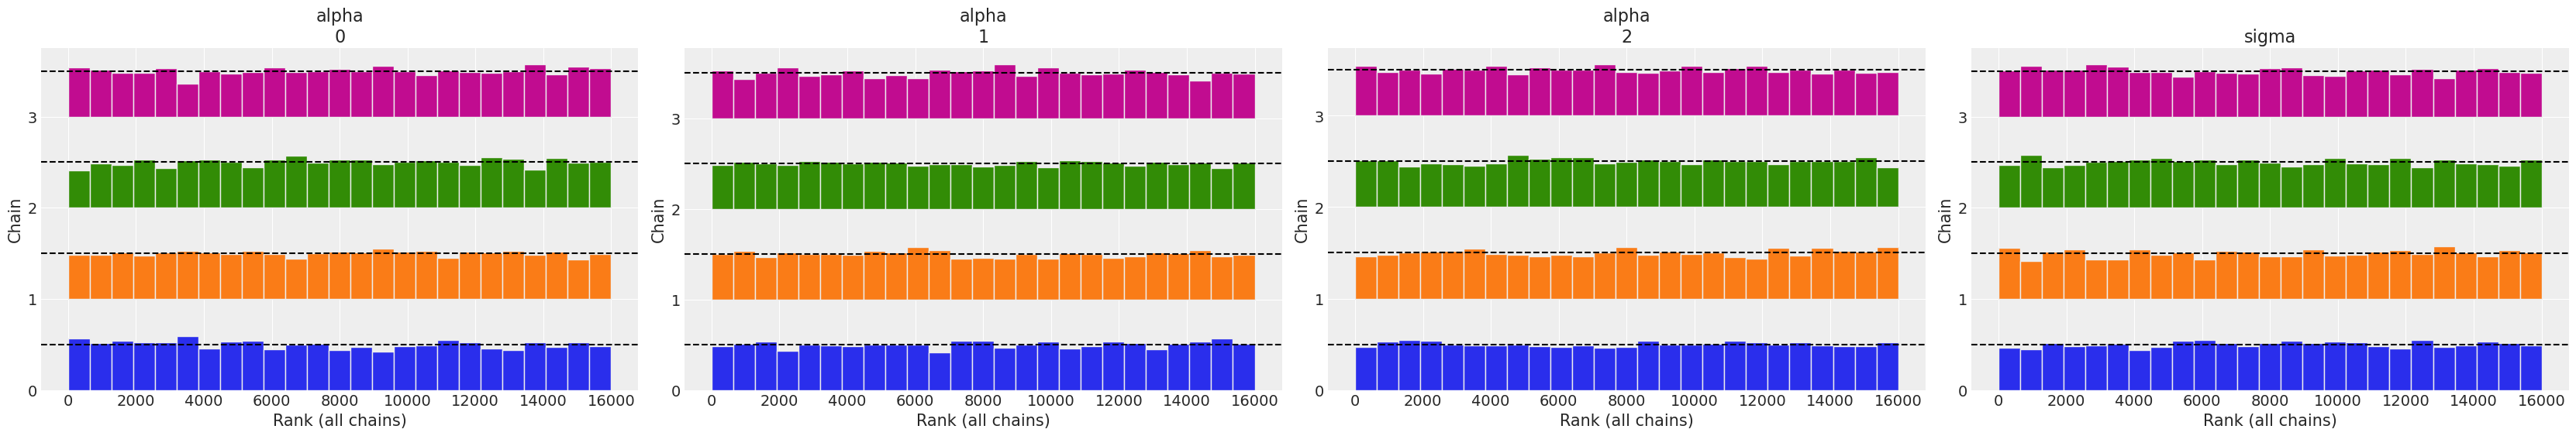

In [30]:
# Plot for specific variables (e.g., your 'phi' and 'sigma')
az.plot_rank(trace_model_1, var_names=["alpha", "sigma"])

/var/folders/j3/904q7dbj02j_jyjz7pvfgz384d40kw/T/ipykernel_63680/3653008493.py:4: UserWarning: The figure layout has changed to tight
  plt.tight_layout() # Helps prevent label overlap


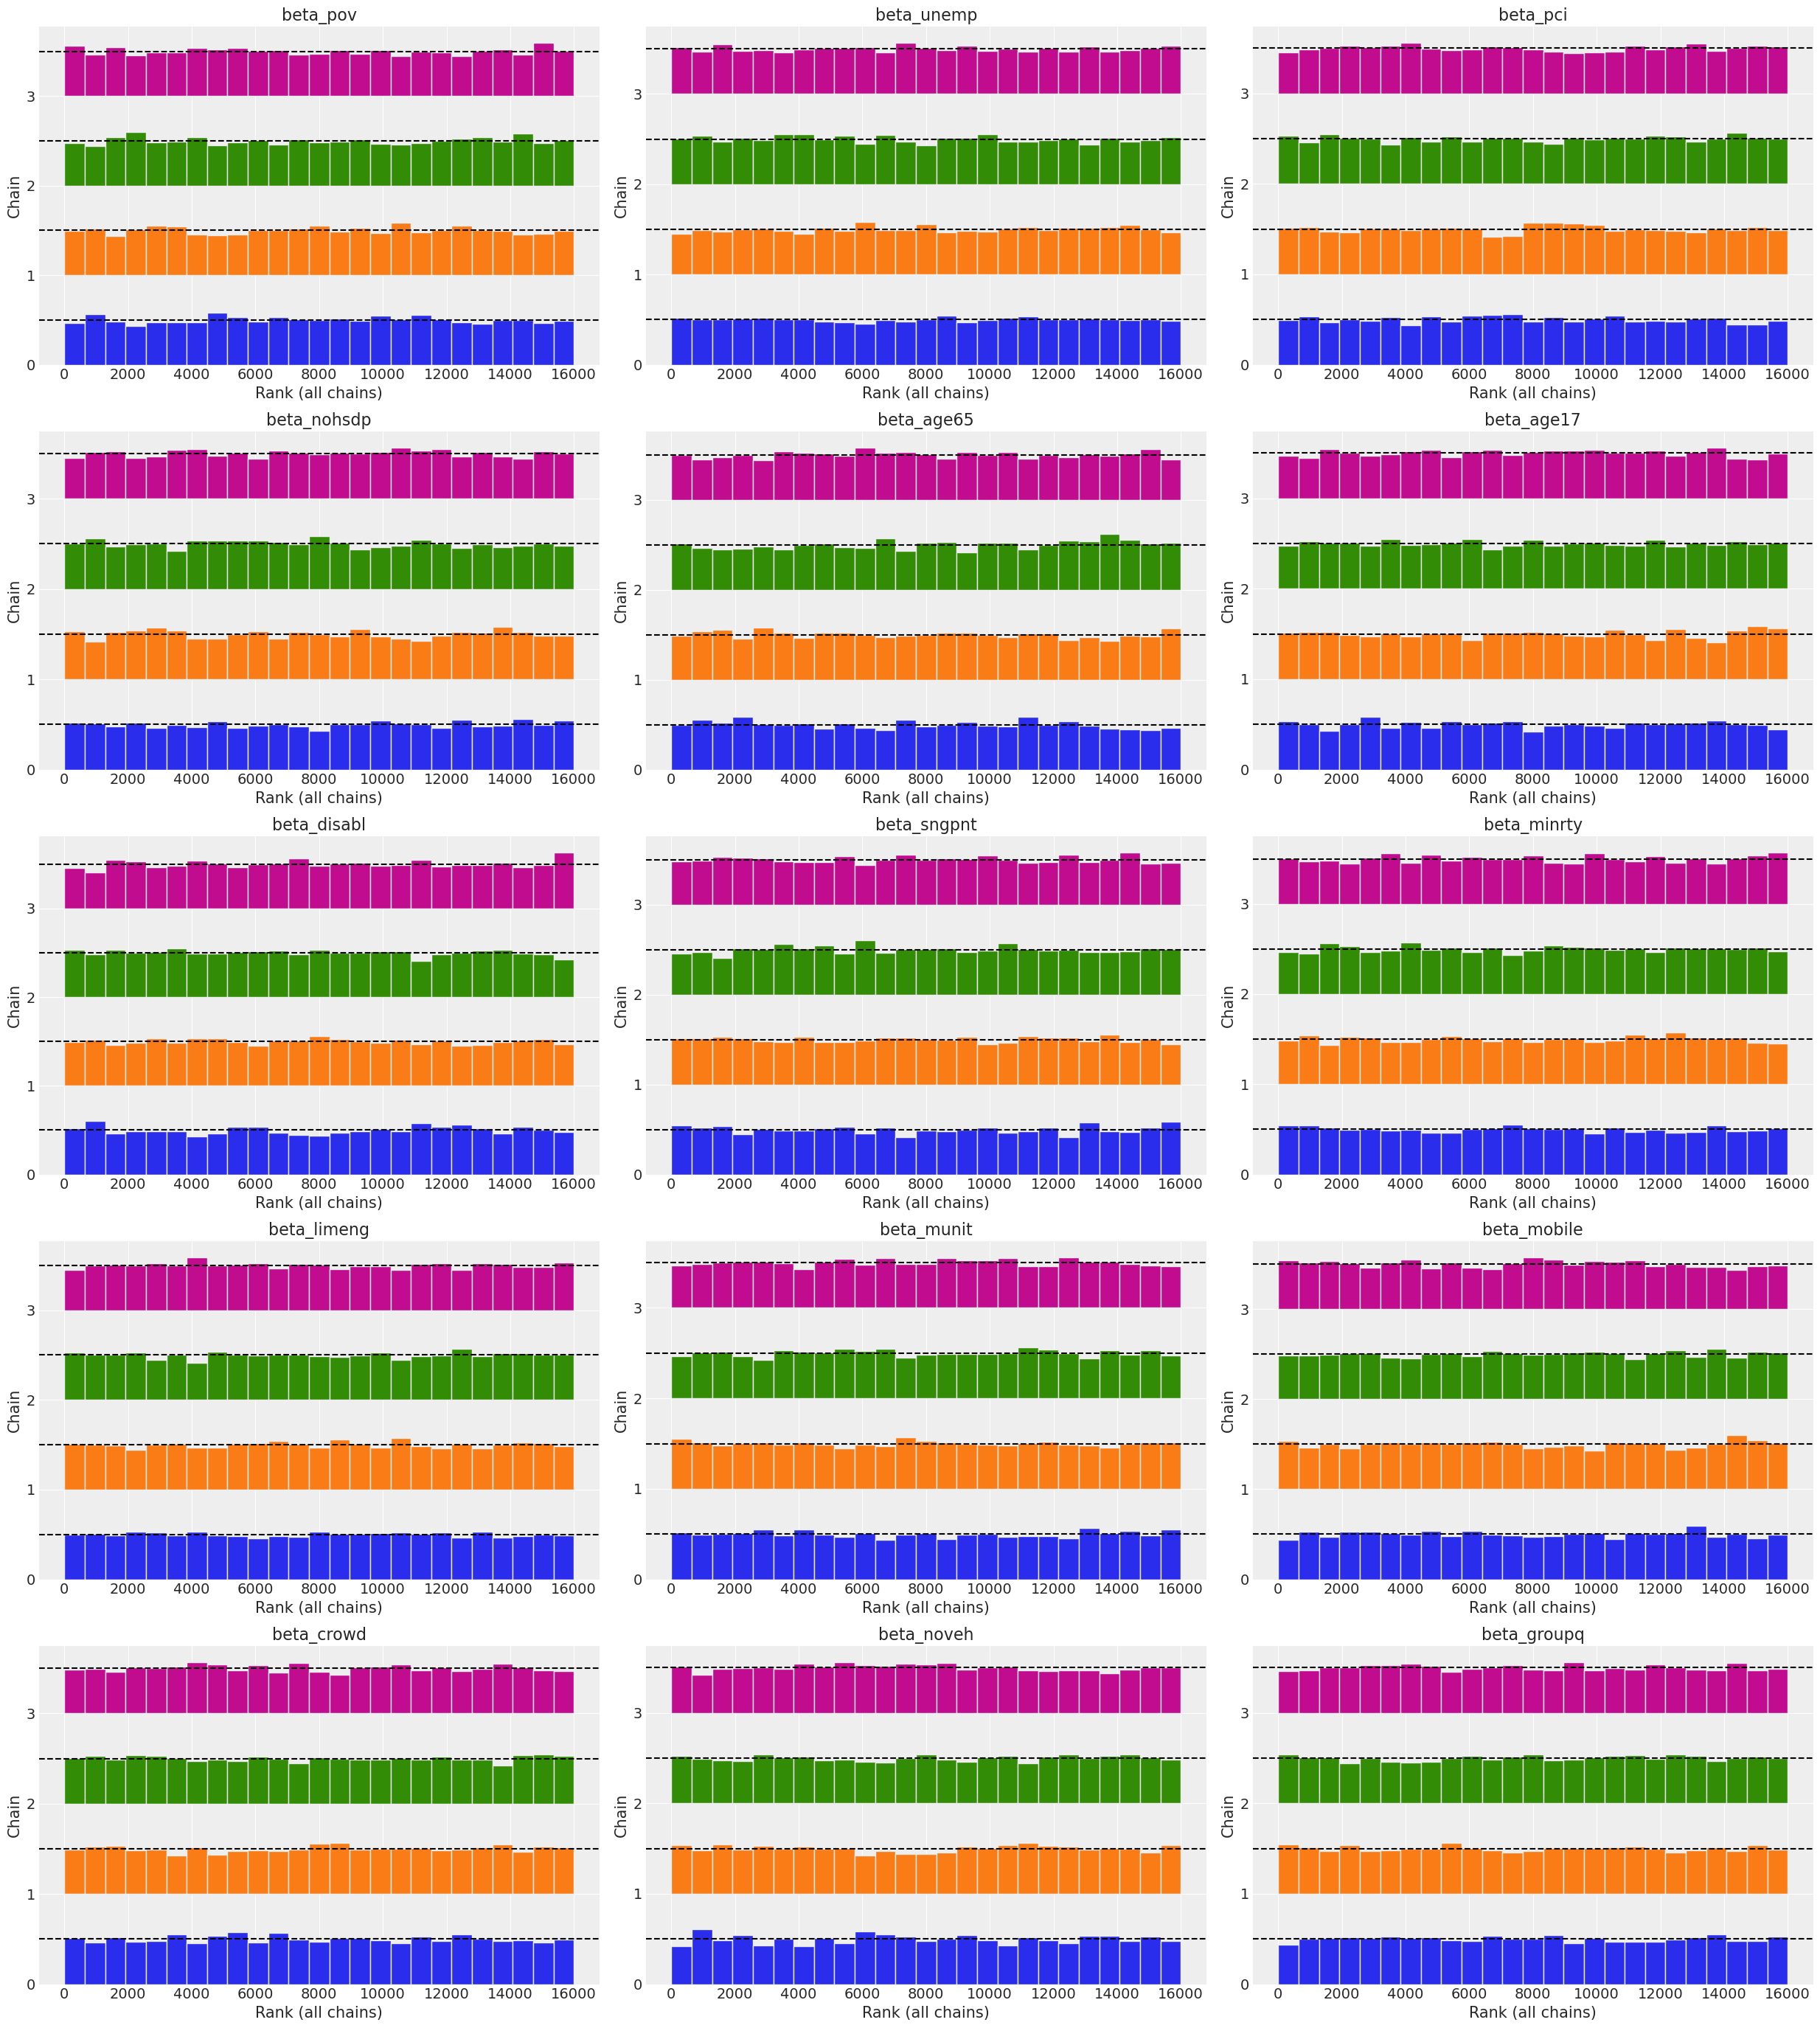

In [31]:
# plot rank plots for all coefficients

az.plot_rank(trace_model_1, var_names=coefficients)
plt.tight_layout() # Helps prevent label overlap

Checking Autocorrlation

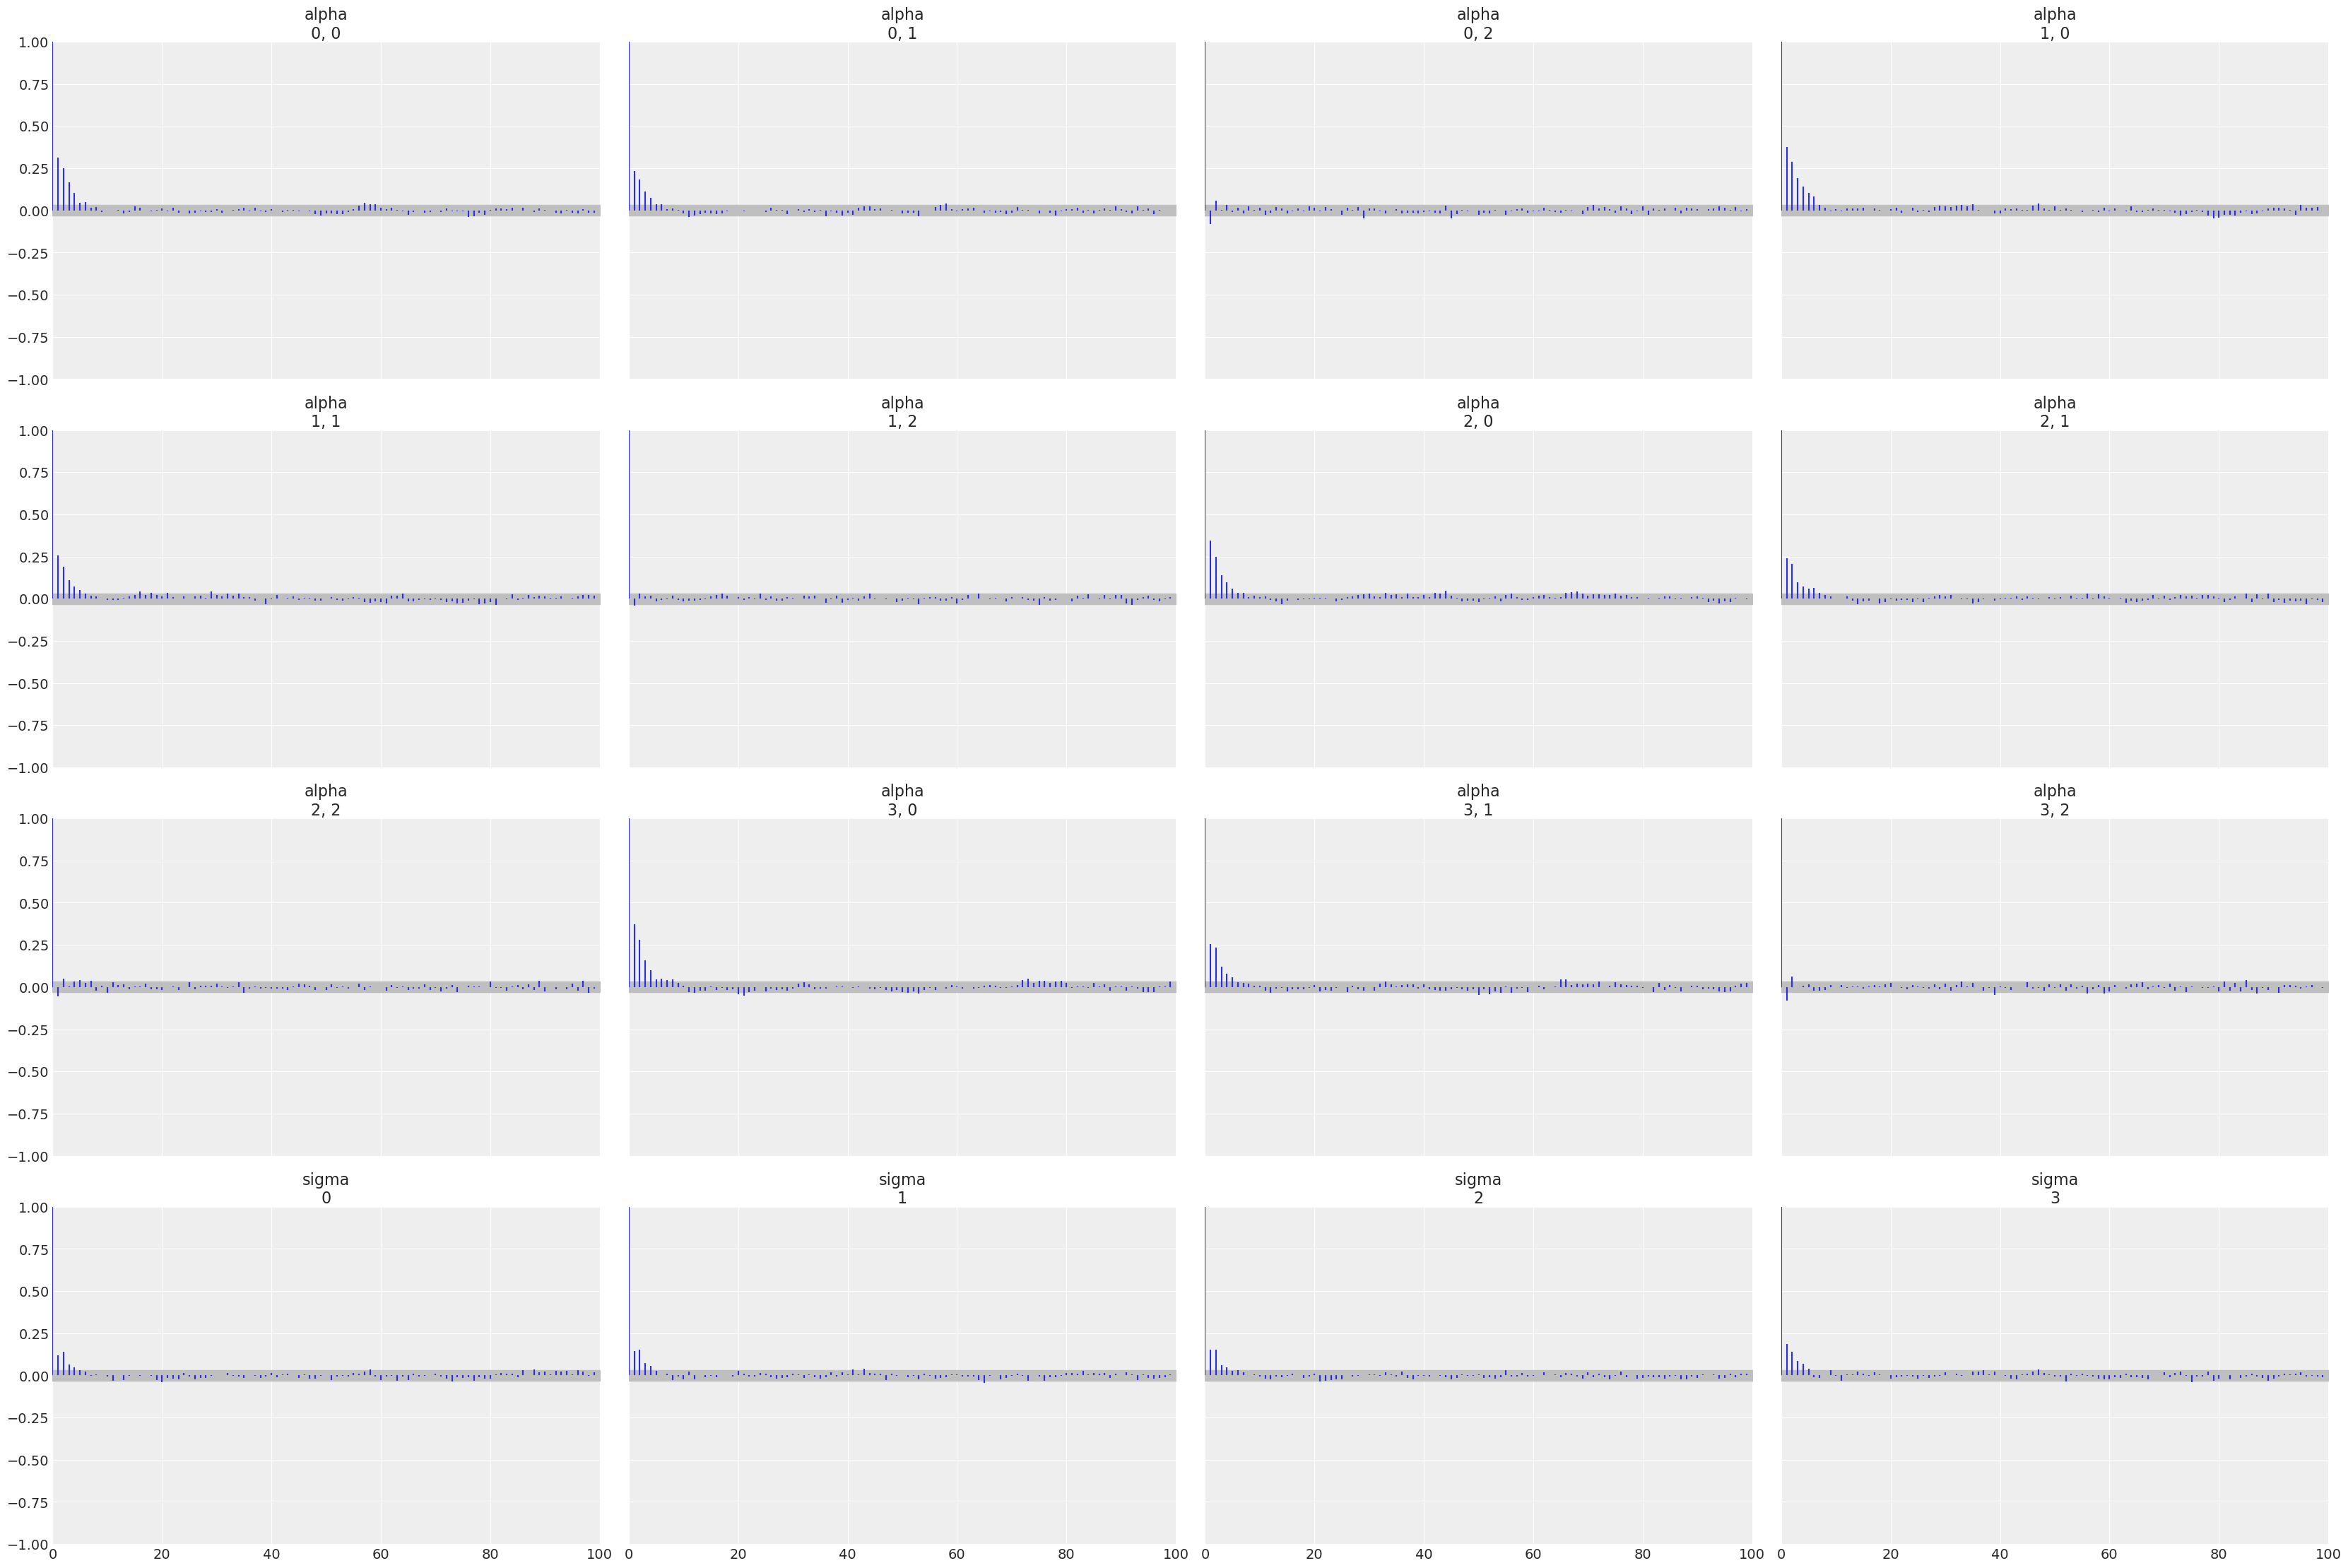

In [32]:
az.plot_autocorr(trace_model_1, var_names=["alpha","sigma"], max_lag=100) 
plt.show()

Monte Carlo Error

In [33]:
summary_model_1 = az.summary(trace_model_1, var_names=["alpha", "sigma"])
print(summary_model_1[["mean", "sd", "ess_bulk", "mcse_mean"]])

           mean     sd  ess_bulk  mcse_mean
alpha[0]  0.164  0.131    4887.0      0.002
alpha[1]  0.468  0.169    6237.0      0.002
alpha[2]  0.368  0.142   15476.0      0.001
sigma     0.471  0.081    8128.0      0.001


In [34]:
# summry all the coefficients in a single dataframe
coeff_summary_model_1 = az.summary(trace_model_1, var_names=coefficients)
print(coeff_summary_model_1)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov    -0.252  0.838  -1.813    1.333      0.005    0.007   24203.0   
beta_unemp  -0.515  0.767  -1.939    0.929      0.005    0.006   21765.0   
beta_pci    -0.245  0.836  -1.846    1.296      0.006    0.007   22807.0   
beta_nohsdp  0.437  0.778  -1.066    1.870      0.005    0.006   21652.0   
beta_age65  -0.545  0.710  -1.921    0.746      0.005    0.005   18039.0   
beta_age17   0.006  0.804  -1.482    1.549      0.006    0.006   20272.0   
beta_disabl  0.442  0.692  -0.842    1.768      0.005    0.005   15951.0   
beta_sngpnt -0.154  0.757  -1.561    1.288      0.005    0.007   23022.0   
beta_minrty  0.059  0.887  -1.687    1.634      0.006    0.007   19606.0   
beta_limeng  0.234  0.764  -1.214    1.631      0.006    0.006   18963.0   
beta_munit   0.101  0.930  -1.611    1.882      0.006    0.008   24093.0   
beta_mobile -0.460  0.596  -1.605    0.630      0.005    0.004   14506.0   
beta_crowd  

In [36]:
comparison_coeff_df = pd.DataFrame(index=coeff_summary_model_1.index)

# 2. Add the current model's means as a column
comparison_coeff_df['Model_BYM'] = coeff_summary_model_1['mean']

# Check the result
print(comparison_coeff_df.head())



             Model_BYM
beta_pov        -0.252
beta_unemp      -0.515
beta_pci        -0.245
beta_nohsdp      0.437
beta_age65      -0.545


Trace plots

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (23), generating only 20 plots
  warnings.warn(


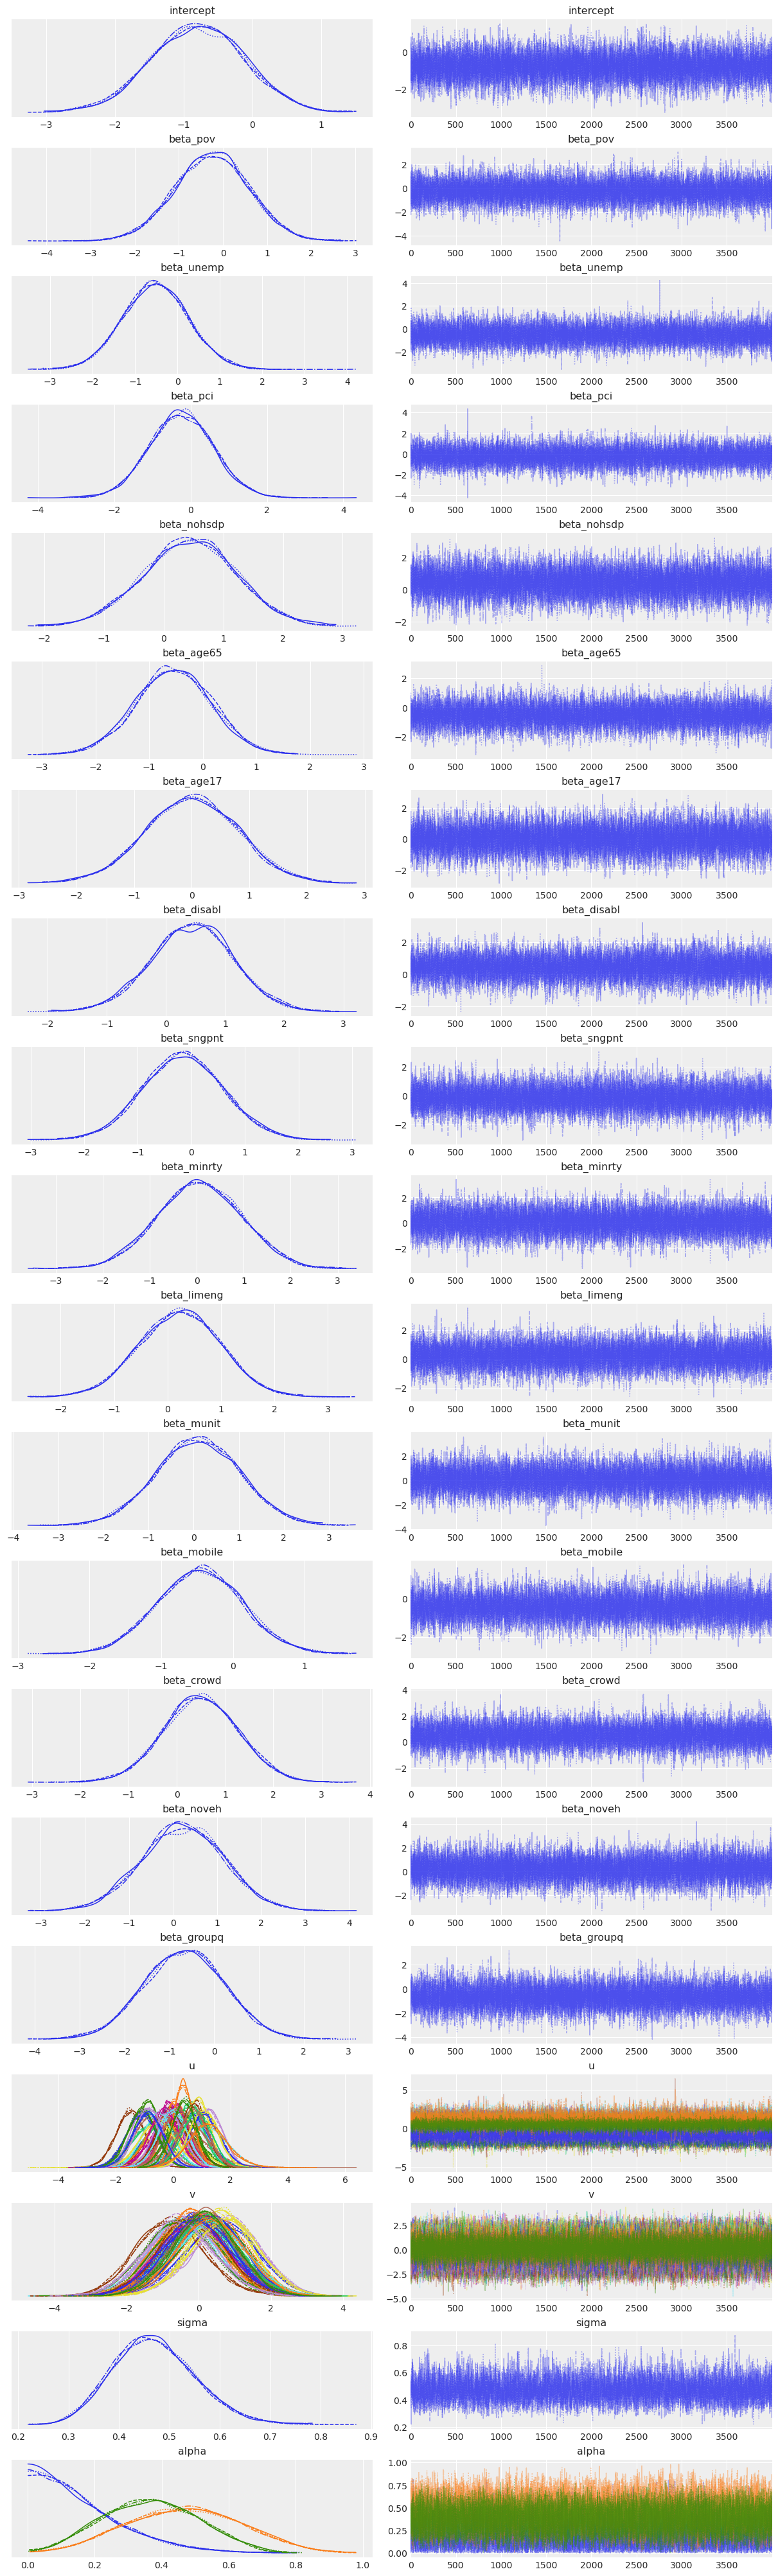

In [37]:
az.plot_trace(trace_model_1)
plt.show()

/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (23), generating only 20 plots
  warnings.warn(


array([[<Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'beta_pov'}>,
        <Axes: title={'center': 'beta_pov'}>],
       [<Axes: title={'center': 'beta_unemp'}>,
        <Axes: title={'center': 'beta_unemp'}>],
       [<Axes: title={'center': 'beta_pci'}>,
        <Axes: title={'center': 'beta_pci'}>],
       [<Axes: title={'center': 'beta_nohsdp'}>,
        <Axes: title={'center': 'beta_nohsdp'}>],
       [<Axes: title={'center': 'beta_age65'}>,
        <Axes: title={'center': 'beta_age65'}>],
       [<Axes: title={'center': 'beta_age17'}>,
        <Axes: title={'center': 'beta_age17'}>],
       [<Axes: title={'center': 'beta_disabl'}>,
        <Axes: title={'center': 'beta_disabl'}>],
       [<Axes: title={'center': 'beta_sngpnt'}>,
        <Axes: title={'center': 'beta_sngpnt'}>],
       [<Axes: title={'center': 'beta_minrty'}>,
        <Axes: title={'center': 'beta_minrty'}>],
       [<Axes: title={'center': 

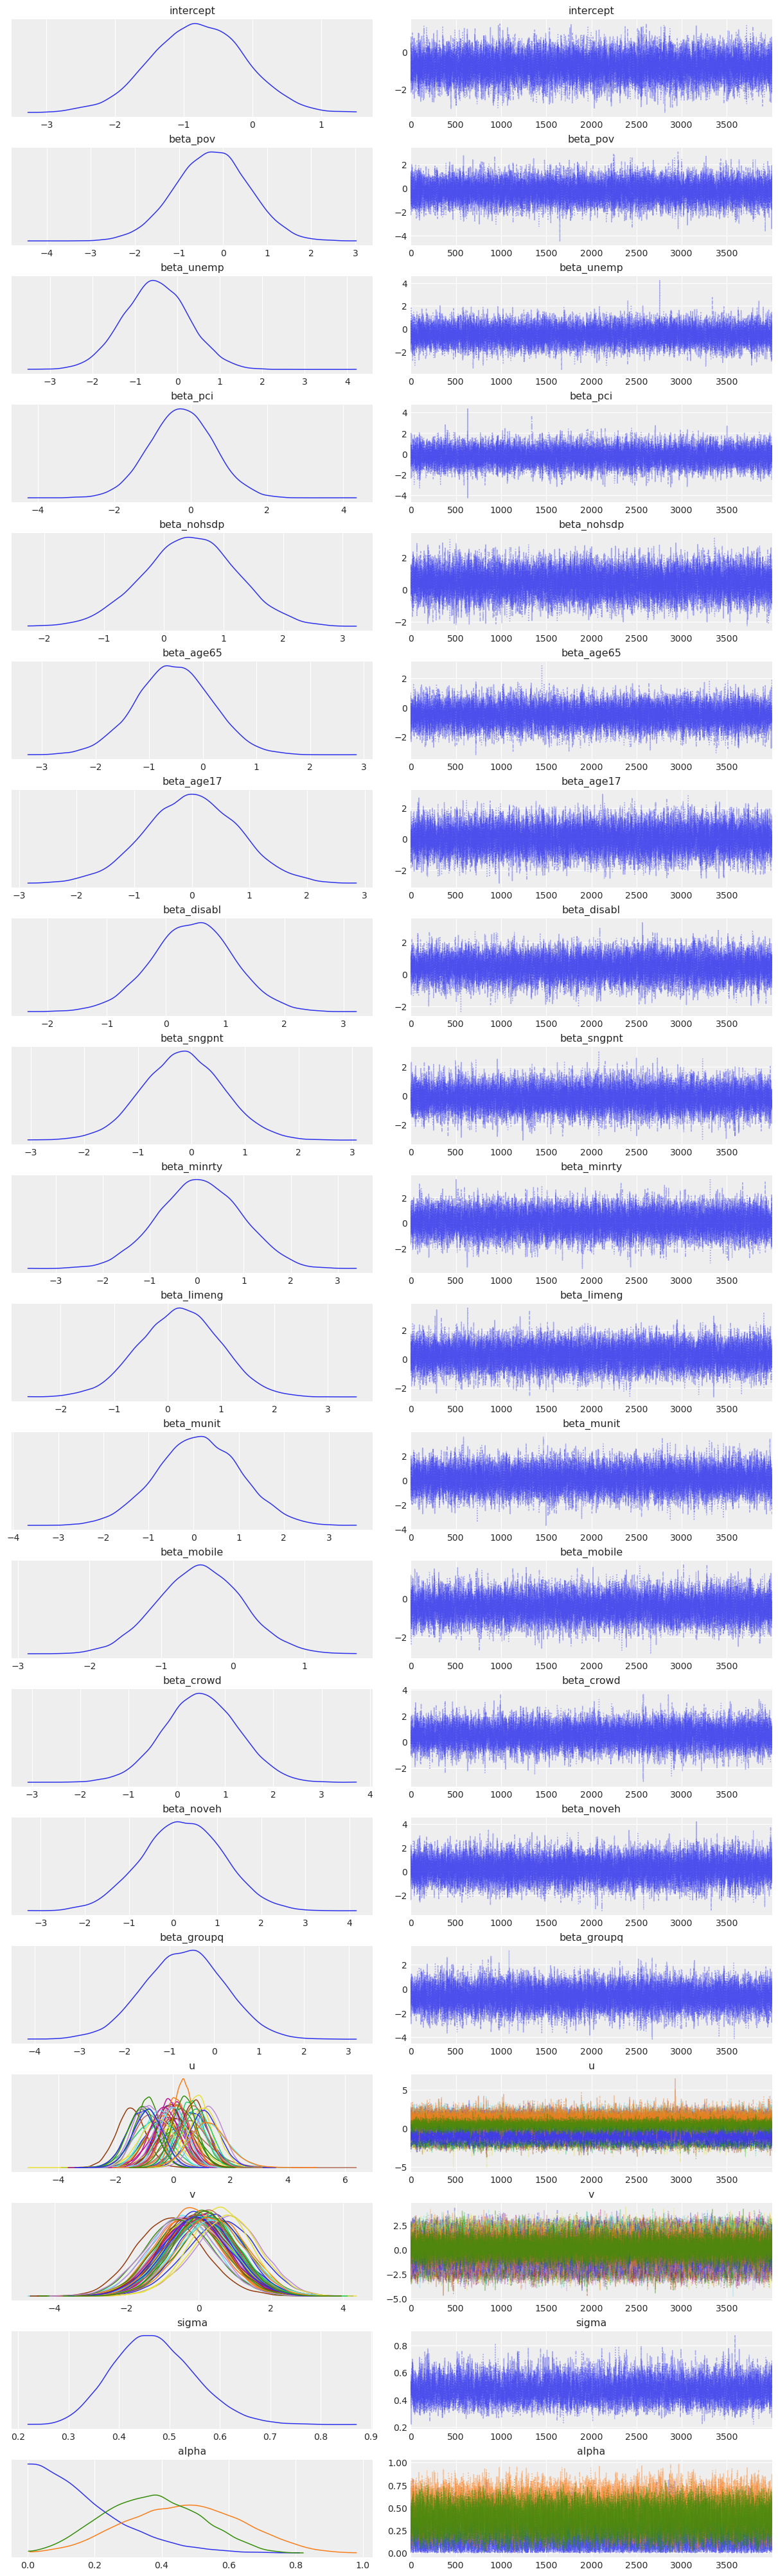

In [38]:
az.plot_trace(trace_model_1, combined=True)

In [40]:
az.summary(trace_model_1, var_names=["alpha","sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],0.164,0.131,0.000,0.405,0.002,0.001,4887.0,8299.0,1.0
alpha[1],0.468,0.169,0.160,0.783,0.002,0.001,6237.0,7606.0,1.0
alpha[2],0.368,0.142,0.117,0.642,0.001,0.001,15476.0,13829.0,1.0
sigma,0.471,0.081,0.320,0.621,0.001,0.001,8128.0,10751.0,1.0


Model metrics WAIC and LOO

In [41]:
loo_result_model_1 = az.loo(trace_model_1)
print(loo_result_model_1)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -143.22     7.25
p_loo       22.94        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       38   71.7%
   (0.70, 1]   (bad)        13   24.5%
   (1, Inf)   (very bad)    2    3.8%



/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [42]:
waic_result_model_1 = az.waic(trace_model_1)
print(waic_result_model_1)

Computed from 16000 posterior samples and 53 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -137.51     6.42
p_waic       17.23        -

There has been a warning during the calculation. Please check the results.


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


####  II. I. BYM-T model 2: The "PC-like" Case (Conservative / Base Model)

In [43]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_2:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)
   beta_unemp = pm.Normal("beta_unemp", mu=0, sigma=1)
   beta_pci = pm.Normal("beta_pci", mu=0, sigma=1)
   beta_nohsdp = pm.Normal("beta_nohsdp", mu=0, sigma=1)
   beta_age65 = pm.Normal("beta_age65", mu=0, sigma=1)
   beta_age17 = pm.Normal("beta_age17", mu=0, sigma=1)
   beta_disabl = pm.Normal("beta_disabl", mu=0, sigma=1)
   beta_sngpnt = pm.Normal("beta_sngpnt", mu=0, sigma=1)
   beta_minrty = pm.Normal("beta_minrty", mu=0, sigma=1)
   beta_limeng = pm.Normal("beta_limeng", mu=0, sigma=1)
   beta_munit = pm.Normal("beta_munit", mu=0, sigma=1)
   beta_mobile = pm.Normal("beta_mobile", mu=0, sigma=1)
   beta_crowd = pm.Normal("beta_crowd", mu=0, sigma=1)
   beta_noveh = pm.Normal("beta_noveh", mu=0, sigma=1)
   beta_groupq = pm.Normal("beta_groupq", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   # Penalizes complexity: Favors Noise > ICAR > TDA
   # Example: 10x more pressure to stay "Noisy" than "Topological"
   alpha = pm.Dirichlet("alpha", a=np.array([5.0, 2.0, 1.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                  beta_unemp * EP_UNEMP_AV_ORI +
                  beta_pci * EP_PCI_AV_ORI +
                  beta_nohsdp * EP_NOHSDP_AV_ORI +
                  beta_age65 * EP_AGE65_AV_ORI +
                  beta_age17 * EP_AGE17_AV_ORI +
                  beta_disabl * EP_DISABL_AV_ORI +
                  beta_sngpnt * EP_SNGPNT_AV_ORI +
                  beta_minrty * EP_MINRTY_AV_ORI +
                  beta_limeng * EP_LIMENG_AV_ORI +
                  beta_munit * EP_MUNIT_AV_ORI +
                  beta_mobile * EP_MOBILE_AV_ORI +
                  beta_crowd * EP_CROWD_AV_ORI +
                  beta_noveh * EP_NOVEH_AV_ORI +
                  beta_groupq * EP_GROUPQ_AV_ORI +
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

In [44]:
with model_2:

    # # Sample from the model:
    trace_model_2 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, beta_unemp, beta_pci, beta_nohsdp, beta_age65, beta_age17, beta_disabl, beta_sngpnt, beta_minrty, beta_limeng, beta_munit, beta_mobile, beta_crowd, beta_noveh, beta_groupq, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 35924 seconds.


In [45]:
# Calculate r_hat for sigma and phi
rhat_data_model_2 = az.rhat(trace_model_2, var_names=["sigma","alpha","beta_pov","beta_unemp","beta_pci","beta_nohsdp","beta_age65","beta_age17","beta_disabl","beta_sngpnt","beta_minrty","beta_limeng","beta_munit","beta_mobile","beta_crowd","beta_noveh","beta_groupq"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_2["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_2["alpha"].values}')

R-hat for sigma: 0.9999742383940673
R-hat for alpha: [1.00014786 1.00041503 0.99996273]


In [46]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_2[var].values}')

R-hat for beta_pov: 0.9999695447412611
R-hat for beta_unemp: 0.9999472183421921
R-hat for beta_pci: 0.9999644515995952
R-hat for beta_nohsdp: 1.0001214871661135
R-hat for beta_age65: 1.000043282418733
R-hat for beta_age17: 1.0002392459473795
R-hat for beta_disabl: 1.0000459678146008
R-hat for beta_sngpnt: 1.0000922577815776
R-hat for beta_minrty: 0.9998859543474817
R-hat for beta_limeng: 0.9999532105583903
R-hat for beta_munit: 1.000100201645111
R-hat for beta_mobile: 1.0000426863059884
R-hat for beta_crowd: 1.000270971706591
R-hat for beta_noveh: 1.000437564405525
R-hat for beta_groupq: 1.000283821288032


In [47]:
# summry all the coefficients in a single dataframe
coeff_summary_model_2 = az.summary(trace_model_2, var_names=coefficients)
print(coeff_summary_model_2)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov    -0.186  0.862  -1.781    1.454      0.005    0.008   28316.0   
beta_unemp  -0.489  0.771  -1.939    0.986      0.005    0.007   27201.0   
beta_pci    -0.162  0.839  -1.712    1.412      0.005    0.007   26143.0   
beta_nohsdp  0.440  0.800  -0.979    2.014      0.005    0.007   25424.0   
beta_age65  -0.612  0.724  -1.942    0.782      0.005    0.006   19945.0   
beta_age17  -0.015  0.808  -1.523    1.496      0.005    0.007   24106.0   
beta_disabl  0.484  0.713  -0.869    1.822      0.006    0.005   16653.0   
beta_sngpnt -0.058  0.792  -1.507    1.475      0.005    0.007   27458.0   
beta_minrty  0.330  0.884  -1.310    1.990      0.006    0.007   25807.0   
beta_limeng  0.262  0.781  -1.209    1.727      0.006    0.006   19498.0   
beta_munit   0.175  0.928  -1.531    1.960      0.006    0.008   27996.0   
beta_mobile -0.537  0.614  -1.684    0.620      0.005    0.004   16531.0   
beta_crowd  

In [48]:
# add the means to the comparison dataframe
comparison_coeff_df['model_2'] = coeff_summary_model_2['mean']

# Check the result
print(comparison_coeff_df)

             Model_BYM  model_2
beta_pov        -0.252   -0.186
beta_unemp      -0.515   -0.489
beta_pci        -0.245   -0.162
beta_nohsdp      0.437    0.440
beta_age65      -0.545   -0.612
beta_age17       0.006   -0.015
beta_disabl      0.442    0.484
beta_sngpnt     -0.154   -0.058
beta_minrty      0.059    0.330
beta_limeng      0.234    0.262
beta_munit       0.101    0.175
beta_mobile     -0.460   -0.537
beta_crowd       0.496    0.454
beta_noveh       0.222    0.396
beta_groupq     -0.668   -0.709


In [49]:
az.summary(trace_model_2, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.457,0.079,0.316,0.609,0.001,0.001,8483.0,11460.0,1.0
alpha[0],0.428,0.144,0.158,0.692,0.002,0.001,9060.0,10760.0,1.0
alpha[1],0.329,0.138,0.079,0.588,0.002,0.001,7771.0,7514.0,1.0
alpha[2],0.244,0.120,0.030,0.460,0.001,0.001,19392.0,12445.0,1.0


####  III. I. BYM-T model 3: The "Favorable" Case (Cluster-Heavy)

In [50]:
# PyMC model for BYM
with pm.Model(coords=coords) as model_3:
    
   # Priors for intercept
   intercept = pm.Normal("intercept", mu=0, sigma=1)

   # Priors regression coefficients
   beta_pov = pm.Normal("beta_pov", mu=0, sigma=1)
   beta_unemp = pm.Normal("beta_unemp", mu=0, sigma=1)
   beta_pci = pm.Normal("beta_pci", mu=0, sigma=1)
   beta_nohsdp = pm.Normal("beta_nohsdp", mu=0, sigma=1)
   beta_age65 = pm.Normal("beta_age65", mu=0, sigma=1)
   beta_age17 = pm.Normal("beta_age17", mu=0, sigma=1)
   beta_disabl = pm.Normal("beta_disabl", mu=0, sigma=1)
   beta_sngpnt = pm.Normal("beta_sngpnt", mu=0, sigma=1)
   beta_minrty = pm.Normal("beta_minrty", mu=0, sigma=1)
   beta_limeng = pm.Normal("beta_limeng", mu=0, sigma=1)
   beta_munit = pm.Normal("beta_munit", mu=0, sigma=1)
   beta_mobile = pm.Normal("beta_mobile", mu=0, sigma=1)
   beta_crowd = pm.Normal("beta_crowd", mu=0, sigma=1)
   beta_noveh = pm.Normal("beta_noveh", mu=0, sigma=1)
   beta_groupq = pm.Normal("beta_groupq", mu=0, sigma=1)

   # Spatial structured effect (CAR)
   u = pm.ICAR("u", W=W, dims="area_idx")

   # Unstructured random effect (iid)/independent random effect
   v = pm.Normal("v", 0, 1, dims="area_idx")

   # TDA effect 
   s = pm.Data("AL_effect", AL, dims="area_idx") #using the standardized AL 

   # joint variance of random effects(b) - Overall variability parameter (sigma acts as 1/sqrt(tau))
   # A sigma of 0.39 in HalfNormal creates a 1% tail probability above 1; This is from Riebler et al. 2016
   sigma = pm.HalfNormal("sigma", 0.39)

    # ----- Dirichlet Mixing for the three random effects -----
    # alpha = [α1, α2, α3] where:
    #   α1: weight for the iid effect (theta)
    #   α2: weight for the spatial (ICAR) effect (phi)
    #   α3: weight for the TDA effect (AL_effect)
   # Penalizes complexity: Favors Noise > ICAR > TDA
   # Biased towards finding the Topological effect
   alpha = pm.Dirichlet("alpha", a=np.array([1.0, 1.0, 4.0]))

   # Combine the three components
   mixture = pm.Deterministic(
        "mixture",
        pt.sqrt(alpha[0]) * v +
        pt.sqrt(alpha[1] / scaling_factor) * u +
        pt.sqrt(alpha[2]) * s,
        dims="area_idx"
    )
   
   # exponential link function to ensure
   # predictions are positive

   mu = pm.Deterministic(
      "mu", pt.exp(log_E + 
                  intercept +
                  beta_pov * EP_POV_AV_ORI + 
                  beta_unemp * EP_UNEMP_AV_ORI +
                  beta_pci * EP_PCI_AV_ORI +
                  beta_nohsdp * EP_NOHSDP_AV_ORI +
                  beta_age65 * EP_AGE65_AV_ORI +
                  beta_age17 * EP_AGE17_AV_ORI +
                  beta_disabl * EP_DISABL_AV_ORI +
                  beta_sngpnt * EP_SNGPNT_AV_ORI +
                  beta_minrty * EP_MINRTY_AV_ORI +
                  beta_limeng * EP_LIMENG_AV_ORI +
                  beta_munit * EP_MUNIT_AV_ORI +
                  beta_mobile * EP_MOBILE_AV_ORI +
                  beta_crowd * EP_CROWD_AV_ORI +
                  beta_noveh * EP_NOVEH_AV_ORI +
                  beta_groupq * EP_GROUPQ_AV_ORI +
                   sigma*mixture), dims="area_idx"
   )

   y_i = pm.Poisson("y_i", mu=mu, observed=y, dims="area_idx") # area_idx needed?
   rr = pm.Deterministic("rr", mu / pt.exp(log_E), dims="area_idx")

In [51]:
with model_3:

    # # Sample from the model:
    trace_model_3 = pm.sample(draws=4000, tune=1500, chains=4, cores=4, target_accept=0.70, idata_kwargs ={"log_likelihood": True}, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_pov, beta_unemp, beta_pci, beta_nohsdp, beta_age65, beta_age17, beta_disabl, beta_sngpnt, beta_minrty, beta_limeng, beta_munit, beta_mobile, beta_crowd, beta_noveh, beta_groupq, u, v, sigma, alpha]


/Users/h6x/anaconda3/envs/pymc_env2/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 4_000 draw iterations (6_000 + 16_000 draws total) took 294 seconds.


In [52]:
# Calculate r_hat for sigma and phi
rhat_data_model_3 = az.rhat(trace_model_3, var_names=["sigma","alpha","beta_pov","beta_unemp","beta_pci","beta_nohsdp","beta_age65","beta_age17","beta_disabl","beta_sngpnt","beta_minrty","beta_limeng","beta_munit","beta_mobile","beta_crowd","beta_noveh","beta_groupq"])

# Print rhat values
print(f'R-hat for sigma: {rhat_data_model_3["sigma"].values}')  
print(f'R-hat for alpha: {rhat_data_model_3["alpha"].values}')

R-hat for sigma: 1.0001263400789666
R-hat for alpha: [1.00046501 1.00009082 0.99998189]


In [53]:
# print rhat for all coefficients
for var in coefficients:
    print(f'R-hat for {var}: {rhat_data_model_3[var].values}')

R-hat for beta_pov: 1.000359065447621
R-hat for beta_unemp: 1.00017625193139
R-hat for beta_pci: 1.0002494943832514
R-hat for beta_nohsdp: 1.0001364766949843
R-hat for beta_age65: 1.0000807055980312
R-hat for beta_age17: 1.0001266442925452
R-hat for beta_disabl: 1.0001984443131118
R-hat for beta_sngpnt: 1.0006097833929606
R-hat for beta_minrty: 1.0005324685997077
R-hat for beta_limeng: 1.0000396044077051
R-hat for beta_munit: 1.0001971830913778
R-hat for beta_mobile: 0.9999943797389229
R-hat for beta_crowd: 0.9999739574354958
R-hat for beta_noveh: 1.0001435751316743
R-hat for beta_groupq: 1.0004363816265742


In [54]:
# summry all the coefficients in a single dataframe
coeff_summary_model_3 = az.summary(trace_model_2, var_names=coefficients)
print(coeff_summary_model_3)

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_pov    -0.186  0.862  -1.781    1.454      0.005    0.008   28316.0   
beta_unemp  -0.489  0.771  -1.939    0.986      0.005    0.007   27201.0   
beta_pci    -0.162  0.839  -1.712    1.412      0.005    0.007   26143.0   
beta_nohsdp  0.440  0.800  -0.979    2.014      0.005    0.007   25424.0   
beta_age65  -0.612  0.724  -1.942    0.782      0.005    0.006   19945.0   
beta_age17  -0.015  0.808  -1.523    1.496      0.005    0.007   24106.0   
beta_disabl  0.484  0.713  -0.869    1.822      0.006    0.005   16653.0   
beta_sngpnt -0.058  0.792  -1.507    1.475      0.005    0.007   27458.0   
beta_minrty  0.330  0.884  -1.310    1.990      0.006    0.007   25807.0   
beta_limeng  0.262  0.781  -1.209    1.727      0.006    0.006   19498.0   
beta_munit   0.175  0.928  -1.531    1.960      0.006    0.008   27996.0   
beta_mobile -0.537  0.614  -1.684    0.620      0.005    0.004   16531.0   
beta_crowd  

In [55]:
# add the means to the comparison dataframe
comparison_coeff_df['model_2'] = coeff_summary_model_3['mean']

# Check the result
print(comparison_coeff_df)

             Model_BYM  model_2
beta_pov        -0.252   -0.186
beta_unemp      -0.515   -0.489
beta_pci        -0.245   -0.162
beta_nohsdp      0.437    0.440
beta_age65      -0.545   -0.612
beta_age17       0.006   -0.015
beta_disabl      0.442    0.484
beta_sngpnt     -0.154   -0.058
beta_minrty      0.059    0.330
beta_limeng      0.234    0.262
beta_munit       0.101    0.175
beta_mobile     -0.460   -0.537
beta_crowd       0.496    0.454
beta_noveh       0.222    0.396
beta_groupq     -0.668   -0.709


In [56]:
az.summary(trace_model_3, var_names=["sigma","alpha"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.483,0.079,0.338,0.631,0.001,0.001,8804.0,10504.0,1.0
alpha[0],0.136,0.106,0.000,0.325,0.001,0.001,6023.0,8451.0,1.0
alpha[1],0.370,0.139,0.118,0.634,0.002,0.001,7181.0,7413.0,1.0
alpha[2],0.494,0.118,0.268,0.704,0.001,0.001,16321.0,13971.0,1.0


##### Compare model results

LOO

In [ ]:
df_comp_loo = az.compare({"bym": loo_result_base,"model_1": loo_result_model_1}, ic="loo")
print(df_comp_loo)

WAIC

In [ ]:
df_comp_waic = az.compare({"bym": waic_result_base, "model_1": waic_result_model_1}, ic="waic")
print(df_comp_waic)

Get sample values to plot the map

In [ ]:
rr_bym = trace_bym.posterior["rr"].mean(dim=["chain", "draw"]).values
rr_model_1 = trace_model_1.posterior["rr"].mean(dim=["chain", "draw"]).values

In [ ]:
combined_data["rr_bym"] = rr_bym
combined_data["rr_model_1"] = rr_model_1


In [ ]:
# lets get the differences to base rr_bym
combined_data["rr_diff_bym_model_1"] = combined_data["rr_model_1"] - combined_data["rr_bym"]

In [ ]:
# let's add missing islands and overdose missing areas back with NaN values
geo_data_for_the_area = geo_data[geo_data['ST_ABBR']==state_abb]

# merge combined_data with geo_data_for_the_area to get all FIPS codes (with NULL values for missing areas)
combined_data_full = geo_data_for_the_area.merge(combined_data, on="FIPS", how="left")

# make combined data into a geodataframe
combined_data_full = gpd.GeoDataFrame(combined_data_full, geometry='geometry_x')

In [ ]:
# plot a map with the relative risk for the BYM model
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_bym", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"bym_relative_risk_map.png"), bbox_inches='tight', dpi=300)

In [ ]:
# plot a map with the relative risk for the model 2
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_model_1", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"bymt_relative_risk_map.png"), bbox_inches='tight', dpi=300)

In [ ]:
# plot a map with the relative risk for the model 2
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

combined_data_full.plot(
    column="rr_model_1", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"bymt_relative_risk_map.png"), bbox_inches='tight', dpi=300)

Plot the differences

In [ ]:
# plot a map with the relative risk for the BYM-T and the BYM model
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white

# Find min/max of your column
vmin = combined_data_full["rr_diff_bym_model_1"].min()
vmax = combined_data_full["rr_diff_bym_model_1"].max()

# Create symmetric range around 0
abs_max = max(abs(vmin), abs(vmax))

combined_data_full.plot(
    column="rr_diff_bym_model_1", 
    ax=ax, 
    legend=True, 
    cmap="RdBu_r", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    vmin=-abs_max,  # ensure 0 is at center
    vmax=abs_max,
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"rr_diff_bymt.png"), bbox_inches='tight', dpi=300)

In [ ]:
# plot a map with AL values for each area
fig, ax = plt.subplots(1, 1, figsize=(12, 8), facecolor='white')  # set figure background to white
ax.set_facecolor("white")  # set axes background to white


combined_data_full.plot(
    column="AL", 
    ax=ax, 
    legend=True, 
    cmap="OrRd", 
    edgecolor="black", 
    linewidth=0.5,
    legend_kwds={"shrink": 0.5},  # Makes the legend smaller
    # Style for NaN values:
    missing_kwds={
        "color": "lightgrey",       # fill color for NaN
        "edgecolor": "black",       # edge color for NaN polygons
        "hatch": "///",             # add hatching for NaN
        "label": "No Data"          # adds entry in legend
    }
)   
# Remove axis ticks for a cleaner map visualization
ax.set_xticks([])
ax.set_yticks([])   

# Show the plot
plt.savefig(os.path.join( current_path, "results",state_abb_lower ,"AL_map.png"), bbox_inches='tight', dpi=300)

Coefficients comparisons

In [ ]:
comparison_coeff_df = comparison_coeff_df.rename(columns={
    "Model_BYM": "BYM",
    "model_1": "BYM-T"
})


In [ ]:
comparison_coeff_df = comparison_coeff_df.rename(index={
    "beta_pov": "Poverty rate",
    "beta_unemp": "Unemployment rate",
    "beta_pci": "Per capita income",
    "beta_nohsdp": "No high school diploma",
    "beta_age65": "Population aged 65+",
    "beta_age17": "Population aged ≤17",
    "beta_disabl": "Disability prevalence",
    "beta_sngpnt": "Single-parent households",
    "beta_minrty": "Minority population",
    "beta_limeng": "Limited English proficiency",
    "beta_munit": "Multi-unit housing",
    "beta_mobile": "Mobile homes",
    "beta_crowd": "Household crowding",
    "beta_noveh": "No vehicle access",
    "beta_groupq": "Group quarters population",
})


In [ ]:
comparison_coeff_df

In [ ]:
comparison_coeff_df.plot(
    kind='barh',
    figsize=(15, 8),
    color=["#1f77b4", "#ff7f0e"]  # blue, orange
)
# plt.xlabel('Coefficient Mean Estimates')
# plt.title('Comparison of Coefficient Estimates Across Models')
plt.tight_layout()
plt.show()

Comparison of sigma, phi, alpha

In [ ]:
# bym model sigma and phi model diagnostics
print(summary[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])

In [ ]:
# model 2 sigma and alpha model diagnostics
print(summary_model_1[["mean", "sd", "ess_bulk","ess_tail", "mcse_mean"]])